In [2]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from movement.filtering import filter_by_confidence, interpolate_over_time
from movement.io import load_poses, save_poses
from movement.kinematics import compute_pairwise_distances
from movement.utils.vector import compute_norm

from scipy.spatial.transform import Rotation as R

# Hide attributes globally
xr.set_options(display_expand_attrs=False)

In [8]:
from pathlib import Path

notebook_path = Path.cwd()
data_dir = notebook_path / "data"

filepath = (
    data_dir
    / "FILE00009_sDLC_DekrW32_seabirdNov6shuffle1_snapshot_170_el_filtered.h5"
)

output_dir = notebook_path / "output"
output_dir.mkdir(parents=True, exist_ok=True)

In [9]:
def get_data_for_load_from_numpy(df):
    """Get array from dataframe to use "from numpy" function"""
    list_individuals = sorted(df.columns.get_level_values("individuals").unique())
    list_keypoints = sorted(df.columns.get_level_values("bodyparts").unique())
    n_keypoints = len(list_keypoints)
    n_individuals = len(list_individuals)

    # position array
    df_position = df.drop(columns=[col for col in df.columns if "likelihood" in col])

    # get number of frames
    position_array = df_position.to_numpy()
    position_array = position_array.reshape(
        df.shape[0],
        2,
        n_keypoints,
        n_individuals,
        order="F",
    )

    # confidence array
    df_confidence = df.drop(
        columns=[col for col in df.columns if "likelihood" not in col]
    )
    confidence_array = df_confidence.to_numpy()
    confidence_array = confidence_array.reshape(
        df.shape[0],
        n_keypoints,
        n_individuals,
        order="F",
    )

    return position_array, confidence_array, list_individuals, list_keypoints

def compute_rotation_to_align_y_axis(vec):
    """Compute rotation to align y-axis"""
    rrot, _rssd = R.align_vectors(
        np.array([[0, 1, 0]]),  # Vector components observed in initial frame A
        vec,  # Vector components observed in another frame B
        return_sensitivity=False,
    )

    return rrot

def add_z_coord_to_position_array(position_array):
    """Add z coordinate to position array"""
    return xr.concat(
        [
            position_array,
            xr.full_like(
                position_array.sel(space="x"),
                0,
            ).expand_dims(space=["z"]),
        ],
        dim="space",
    )

In [ ]:
df = pd.read_hdf(filepath)

Droping the "single" (e.g. boat) keypoints

In [14]:
if (filepath.parent / (filepath.stem + "_birds.h5")).exists():
    ds_birds = load_poses.from_dlc_file(filepath.parent / (filepath.stem + "_birds.h5"))
else:
    columns_to_drop = [col for col in df.columns if "single" in col]
    df_birds = df.drop(columns=columns_to_drop)

    position_array, confidence_array, list_individuals, list_keypoints = (
        get_data_for_load_from_numpy(df_birds)
    )

    ds_birds = load_poses.from_numpy(
        position_array=position_array,
        confidence_array=confidence_array,
        individual_names=list_individuals,
        keypoint_names=list_keypoints,
        # fps=30,
    )

    # export to file importable in napari
    # To visualise exported file, follow this guide:
    # https://movement.neuroinformatics.dev/user_guide/gui.html
    save_poses.to_dlc_file(ds_birds, filepath.parent / (filepath.stem + "_birds.h5"))


Get dataset with boat data only

In [15]:
if (filepath.parent / (filepath.stem + "_boat.h5")).exists():
    ds_boat = load_poses.from_dlc_file(filepath.parent / (filepath.stem + "_boat.h5"))
else:
    columns_to_drop = [col for col in df.columns if "bird" in col[1]]
    df_boat = df.drop(columns=columns_to_drop)

    position_array, confidence_array, list_individuals, list_keypoints = (
        get_data_for_load_from_numpy(df_boat)
    )

    ds_boat = load_poses.from_numpy(
        position_array=position_array,
        confidence_array=confidence_array,
        individual_names=list_individuals,
        keypoint_names=list_keypoints,
        # fps=30,
    )

    # export for importable in napari
    save_poses.to_dlc_file(
        ds_boat, filepath.parent / (filepath.stem + "_boat.h5"), split_individuals=False
    )

For birds, filter the low-confidence values 

In [16]:
confidence_threshold = 0.5

boat_position = filter_by_confidence(
    ds_boat.position, ds_boat.confidence, threshold=confidence_threshold
)
birds_position = filter_by_confidence(
    ds_birds.position, ds_birds.confidence, threshold=confidence_threshold
)

# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Linearly interpolate boat points
# (gaps with nan are linearly inteprolated)
boat_position_interp = interpolate_over_time(
    boat_position,
    method="linear",
    print_report=True,
)  # there should be no nans after interp


Missing points (marked as NaN) in input:

keypoints             boatBL
individuals                 
single       24/9000 (0.27%)
No missing points (marked as NaN) in output.


We need to rotate because the boat is meaningful physical reference. 

When we change to BCS, the origin is the boat center, the y-axis is showing the boat forward direction, and the x-axis is shoing left-right from the boat. 

In this block we're not transforming the data yet. 

In [18]:
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Compute rotation to BCS (boat coordinate system)
# - origin : centroid of all boat keypoints per frame
# - y-axis: vector from boat centroid to tip keypoint
# - x-axis: perpendicular to y-axis, points to left side of the boat
#   (it is a rotation from the image coordinate system (ICS))

# Note: we need to flip the x-coord to match the "classic plot"
# coordinate system (x-axis from left to right, y-axis from bottom to top).
# We cannot rotate the ICS into the "classic plot", it needs a flip of
# the x-axis.


# compute origin
boat_position_3d = add_z_coord_to_position_array(boat_position_interp)
boat_centroid_3d = boat_position_3d.mean("keypoints")

# compute y-axis
boat_y_axis_3d = (
    boat_position_3d.sel(keypoints="boatTip") - boat_centroid_3d
).drop_vars(["keypoints"])
boat_centroid_3d = boat_centroid_3d.drop_vars("individuals").squeeze()
boat_y_axis_3d = boat_y_axis_3d.drop_vars("individuals").squeeze()

# compute rotation from ICS y-axis to BCS y-axis
rotation2boat = xr.apply_ufunc(
    lambda v: compute_rotation_to_align_y_axis(v),
    boat_y_axis_3d,
    input_core_dims=[["space"]],
    vectorize=True,
)


compute birds keypoints in BCS (translated and rotated)

In [20]:
birds_position_3d = add_z_coord_to_position_array(birds_position)

birds_position_3d_BCS = xr.apply_ufunc(
    lambda rot, trans, vec: rot.apply(vec - trans),
    rotation2boat,  # rot
    boat_centroid_3d,  # trans
    birds_position_3d,  # vec
    input_core_dims=[[], ["space"], ["space"]],
    output_core_dims=[["space"]],
    vectorize=True,
)

# drop z coordinate
birds_position_BCS = birds_position_3d_BCS.drop_sel(space="z")


In [22]:
boat_position_3d_BCS = xr.apply_ufunc(
    lambda rot, trans, vec: rot.apply(vec - trans),
    rotation2boat,  # rot
    boat_centroid_3d,  # trans
    boat_position_3d,  # vec
    input_core_dims=[[], ["space"], ["space"]],
    output_core_dims=[["space"]],
    vectorize=True,
)

# drop z coordinate
boat_position_BCS = boat_position_3d_BCS.drop_sel(space="z")

Apply scaling

Calculate boat width and the length per frame, because the drone is moving and the size of the boat changes. 

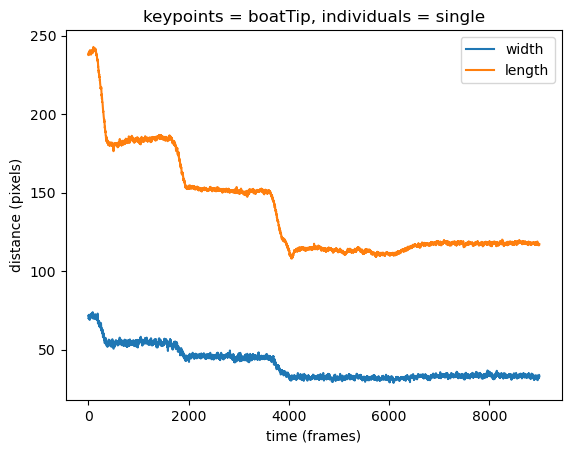

In [23]:
# Apply scaling

# Compute boat width and length per frame in pixels
boat_width = compute_pairwise_distances(
    boat_position_BCS, dim="keypoints", pairs={"boatBL": "boatBR"}
)
# boat_width.name = "position"

boat_midpoint_BL_BR = boat_position_BCS.sel(keypoints=["boatBL", "boatBR"]).mean(
    dim="keypoints"
)
boat_length = compute_norm(
    boat_position_BCS.sel(keypoints="boatTip") - boat_midpoint_BL_BR
).squeeze()


# check with plot
plt.figure()
boat_width.plot(label="width")
boat_length.plot(label="length")
plt.xlabel("time (frames)")
plt.ylabel("distance (pixels)")
plt.legend()


We convert from camera-pixels to meters: 

Because pixels are camera-dependent and meaningless physically, while meters are interpretable, comparable, and analyzable.

Also, if we change to meters we solve the problem of the scaling, because we just set a scaling factor from pixels (boat tip and bottom) to meters, so that everything is equal. 


In [26]:
# Express spatial coordinates in meters
boat_max_length_in_m = 8.55  # m
boat_max_width_in_m = 2.95  # m

# We use boat length to scale the data
scale_factor = (
    boat_max_length_in_m / boat_length
)  # (boat_max_width_in_m / boat_width) - looks nosier
boat_position_BCS_in_m = boat_position_BCS * scale_factor
birds_position_BCS_in_m = birds_position_BCS * scale_factor


Here we're just going to plot the results of the transformation. So we're going to plot the birds trajectories centered to coordinate 0,0 BSC. 

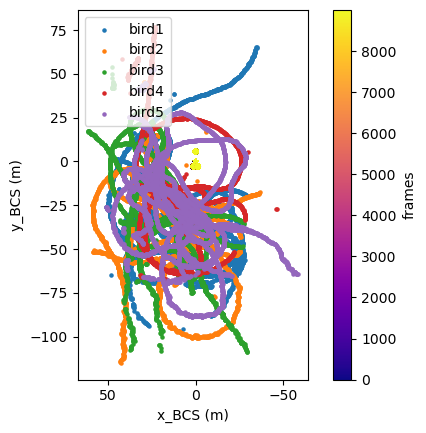

In [27]:
# Plot data in BCS

# Select a time slice for clarity (frames 0 to 654)
time_slice = slice(0, 9000)

fig, ax = plt.subplots(1, 1)

# plot bird data and color by individual
cmap = plt.get_cmap("tab10")
color_array = cmap(np.arange(len(birds_position_BCS_in_m.individuals)))

for i, ind in enumerate(birds_position_BCS_in_m.individuals):
    # bird centroids
    ax.scatter(
        birds_position_BCS_in_m.sel(time=time_slice, individuals=ind, space="x").mean(
            "keypoints"
        ),
        birds_position_BCS_in_m.sel(time=time_slice, individuals=ind, space="y").mean(
            "keypoints"
        ),
        5,
        color=color_array[i],
        label=ind.item(),
    )

ax.legend(loc="upper right", bbox_to_anchor=(1.02, 1))

# plot boat centroid
sc = ax.scatter(
    boat_position_BCS_in_m.sel(time=time_slice, space="x").mean("keypoints"),
    boat_position_BCS_in_m.sel(time=time_slice, space="y").mean("keypoints"),
    10,
    c=np.arange((time_slice.stop - time_slice.start)),
    cmap="plasma",
    marker="*",
)

# plot boat keypoints in time
for boat_keypoint in ["boatTip", "boatBL", "boatBR"]:
    ax.scatter(
        boat_position_BCS_in_m.sel(time=time_slice, keypoints=boat_keypoint, space="x"),
        boat_position_BCS_in_m.sel(time=time_slice, keypoints=boat_keypoint, space="y"),
        10,
        c=np.arange((time_slice.stop - time_slice.start)),
        cmap="plasma",
    )

ax.set_xlabel("x_BCS (m)")
ax.set_ylabel("y_BCS (m)")
ax.set_aspect("equal")
ax.invert_xaxis()

# add colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("frames")

# put legend top left
ax.legend(loc="upper left")

Save the datasets

.to_netcdf() saves your xarray DataArray to a NetCDF (.nc) file, which preserves multidimensional structure, labels, and metadata, making it ideal for storing processed, analysis-ready spatiotemporal tracking data.

In [28]:
birds_position_BCS_in_m.to_netcdf(output_dir / "birds_position_BCS_in_m.nc")
boat_position_BCS_in_m.to_netcdf(output_dir / "boat_position_BCS_in_m.nc")

Plotting as a video

Saved: output/bcs_animation.mp4


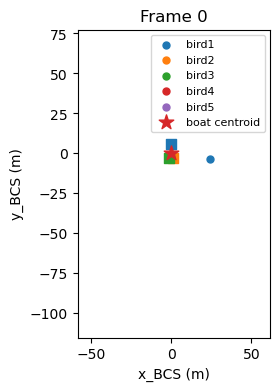

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- settings ---
time_start, time_stop = 0, 9000
step = 5  # downsample frames for speed (e.g., 1 = every frame, 5 = every 5th frame)
frames = np.arange(time_start, time_stop, step)

# --- prep figure ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.set_xlabel("x_BCS (m)")
ax.set_ylabel("y_BCS (m)")
ax.set_aspect("equal")
ax.invert_xaxis()

# fixed axes limits so the plot doesn't jump around
# (use data-driven limits from the selected slice)
bx = boat_position_BCS_in_m.sel(time=slice(time_start, time_stop), space="x")
by = boat_position_BCS_in_m.sel(time=slice(time_start, time_stop), space="y")
x_all = np.concatenate([bx.values.ravel()])
y_all = np.concatenate([by.values.ravel()])

for ind in birds_position_BCS_in_m.individuals.values:
    x = birds_position_BCS_in_m.sel(individuals=ind, time=slice(time_start, time_stop), space="x").mean("keypoints").values
    y = birds_position_BCS_in_m.sel(individuals=ind, time=slice(time_start, time_stop), space="y").mean("keypoints").values
    m = np.isfinite(x) & np.isfinite(y)
    x_all = np.concatenate([x_all, x[m]])
    y_all = np.concatenate([y_all, y[m]])

pad = 0.5
ax.set_xlim(np.nanmin(x_all) - pad, np.nanmax(x_all) + pad)
ax.set_ylim(np.nanmin(y_all) - pad, np.nanmax(y_all) + pad)

# --- artists: birds (centroids) ---
cmap = plt.get_cmap("tab10")
inds = list(birds_position_BCS_in_m.individuals.values)
colors = cmap(np.arange(len(inds)))

bird_scatters = []
for i, ind in enumerate(inds):
    sc = ax.scatter([], [], s=25, color=colors[i], label=str(ind))
    bird_scatters.append(sc)

# --- artists: boat keypoints ---
boat_kps = ["boatTip", "boatBL", "boatBR"]
boat_scatters = {kp: ax.scatter([], [], s=60, marker="s") for kp in boat_kps}

# boat centroid
boat_centroid_sc = ax.scatter([], [], s=120, marker="*", label="boat centroid")

ax.legend(loc="upper right", fontsize=8)

title = ax.set_title("")

def update(t):
    # update title
    title.set_text(f"Frame {t}")

    # update birds
    for i, ind in enumerate(inds):
        x = birds_position_BCS_in_m.sel(time=t, individuals=ind, space="x").mean("keypoints").values
        y = birds_position_BCS_in_m.sel(time=t, individuals=ind, space="y").mean("keypoints").values
        if np.isfinite(x) and np.isfinite(y):
            bird_scatters[i].set_offsets([[x, y]])
        else:
            bird_scatters[i].set_offsets([[np.nan, np.nan]])

    # update boat keypoints
    for kp in boat_kps:
        xk = boat_position_BCS_in_m.sel(time=t, keypoints=kp, space="x").values
        yk = boat_position_BCS_in_m.sel(time=t, keypoints=kp, space="y").values
        boat_scatters[kp].set_offsets([[xk, yk]])

    # update boat centroid
    cx = boat_position_BCS_in_m.sel(time=t, space="x").mean("keypoints").values
    cy = boat_position_BCS_in_m.sel(time=t, space="y").mean("keypoints").values
    boat_centroid_sc.set_offsets([[cx, cy]])

    return bird_scatters + list(boat_scatters.values()) + [boat_centroid_sc, title]

anim = FuncAnimation(fig, update, frames=frames, interval=30, blit=False)

# --- save ---
out_path = "output/bcs_animation.mp4"
anim.save(out_path, fps=30)  # adjust fps to taste
print("Saved:", out_path)